Question 1

a)

In [1]:
import pandas as pd
import numpy as np

In [2]:
file_name = "lines.csv"

In [3]:
try:
    D = np.genfromtxt(file_name, delimiter=",", skip_header=1)
    
    # 2. Extract the data corresponding to the first line (x1 and y1)
    x1 = D[:, 0]
    y1 = D[:, 3]
    
    # 3. Calculate the centroids
    x_mean = np.mean(x1)
    y_mean = np.mean(y1)
    
    # 4. Center the data
    X_centered = x1 - x_mean
    Y_centered = y1 - y_mean
    
    # 5. Construct matrix A and perform SVD
    A = np.vstack((X_centered, Y_centered)).T
    U, S, Vt = np.linalg.svd(A)
    
    # 6. The normal vector (a, b) is the last row of V-transpose
    a, b = Vt[-1, :]
    
    # 7. Calculate final slope (m) and intercept (c)
    m = -a / b
    c = y_mean - m * x_mean

    print("=== Total Least Squares Fit (Line 1) ===")
    print(f"Slope (m): {m:.4f}")
    print(f"Y-Intercept (c): {c:.4f}")
    print(f"Line Equation: y = {m:.4f}x + {c:.4f}")

except FileNotFoundError:
    print(f"Error: Could not find '{file_name}'. Please ensure the file is in the same directory as this script.")

=== Total Least Squares Fit (Line 1) ===
Slope (m): 1.2207
Y-Intercept (c): -5.9872
Line Equation: y = 1.2207x + -5.9872


b)

In [4]:
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

In [5]:
points = np.column_stack((X_all, Y_all))

In [6]:
def tls_fit(pts):
    x, y = pts[:, 0], pts[:, 1]
    x_mean, y_mean = np.mean(x), np.mean(y)

    # Center the data and perform SVD
    A = np.vstack((x - x_mean, y - y_mean)).T
    _, _, Vt = np.linalg.svd(A)
    a, b = Vt[-1, :]

    # Return line parameters (a, b, c) for ax + by + c = 0
    c = -(a * x_mean + b * y_mean)
    return a, b, c

In [7]:
def find_single_line_ransac(pts, iterations=1000, threshold=0.5):
    best_inliers = []

    for _ in range(iterations):
        sample_idx = np.random.choice(len(pts), 2, replace=False)
        p1, p2 = pts[sample_idx]

        line = np.cross([p1[0], p1[1], 1], [p2[0], p2[1], 1])
        a, b, c = line

        norm = np.hypot(a, b)
        if norm == 0:
            continue
        a, b, c = a/norm, b/norm, c/norm

        distances = np.abs(a * pts[:, 0] + b * pts[:, 1] + c)

        inlier_idx = np.where(distances < threshold)[0]

        if len(inlier_idx) > len(best_inliers):
            best_inliers = inlier_idx

    if len(best_inliers) > 0:
        inlier_pts = pts[best_inliers]
        refined_model = tls_fit(inlier_pts)
        return refined_model, best_inliers

    return None, []

In [8]:
remaining_points = points.copy()
lines_found = []

distance_threshold = 0.5

In [9]:
for i in range(3):
    print(f"\n--- Searching for Line {i+1} ---")

    model, inlier_idx = find_single_line_ransac(
        remaining_points,
        iterations=2000,
        threshold=distance_threshold
    )

    if model is None:
        print("Not enough points to find another line.")
        break

    a, b, c = model
    m = -a / b
    c_int = -c / b

    lines_found.append((m, c_int))
    print(f"Result: y = {m:.4f}x + {c_int:.4f}")
    print(f"Inliers found: {len(inlier_idx)}")

    remaining_points = np.delete(remaining_points, inlier_idx, axis=0)
    print(f"Points remaining for next search: {len(remaining_points)}")


--- Searching for Line 1 ---
Result: y = -0.5075x + 2.1751
Inliers found: 84
Points remaining for next search: 216

--- Searching for Line 2 ---
Result: y = 1.0319x + 1.0806
Inliers found: 68
Points remaining for next search: 148

--- Searching for Line 3 ---
Result: y = 1.2851x + -5.9915
Inliers found: 65
Points remaining for next search: 83


Question 2

In [9]:
import cv2

In [10]:
image = cv2.imread('earrings (1).jpg')

In [12]:
def measure_earring_size(image):

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    _, thresh = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return "No objects detected."

    largest_contour = max(contours, key=cv2.contourArea)

    x, y, w, h = cv2.boundingRect(largest_contour)

    pixels_measured = h

    Z = 720.0
    f = 8.0
    p = 2.2 * (10 ** -3)

    real_height_mm = (Z * pixels_measured * p) / f

    return pixels_measured, real_height_mm

In [13]:
result = measure_earring_size(image)

In [14]:
if isinstance(result, tuple):
    pixels, size_mm = result
    print(f"Detected Earring Height: {pixels} pixels")
    print(f"Calculated Physical Height: {size_mm:.2f} mm")
else:
    print(result)

Detected Earring Height: 1024 pixels
Calculated Physical Height: 202.75 mm


Question 3

In [1]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
N = 6 
n=0
p1 = np.empty((N, 2))
p2 = np.empty((N, 2))

In [3]:
def draw_circle(event, x, y, flags, param):
    global n
    p = param[0]
    if event == cv2.EVENT_LBUTTONDOWN:
        cv2.circle(param[1], (x, y), 5, (255, 0, 0), -1)
        p[n] = (x, y)
        n += 1
        cv2.imshow(param[2], param[1])

In [4]:
im1 = cv2.imread('c1.jpg') 
im2 = cv2.imread('c2.jpg')

In [5]:
gray1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

In [6]:
im1copy = im1.copy()
im2copy = im2.copy()

a)

In [7]:
print(f"Please click {N} corresponding points on Image 1, then press ESC.")
param = [p1, im1copy, 'Image 1']
cv2.namedWindow('Image 1', cv2.WINDOW_NORMAL)
cv2.setMouseCallback('Image 1', draw_circle, param)

while(1):
    cv2.imshow("Image 1", im1copy)
    if n == N:
        break
    if cv2.waitKey(20) & 0xFF == 27:
        break
cv2.destroyWindow('Image 1')

Please click 6 corresponding points on Image 1, then press ESC.


In [8]:
n = 0 
print(f"Please click {N} corresponding points on Image 2 in the EXACT SAME ORDER, then press ESC.")
param = [p2, im2copy, 'Image 2']
cv2.namedWindow('Image 2', cv2.WINDOW_NORMAL)
cv2.setMouseCallback('Image 2', draw_circle, param)

Please click 6 corresponding points on Image 2 in the EXACT SAME ORDER, then press ESC.


In [9]:
while(1):
    cv2.imshow("Image 2", im2copy)
    if n == N:
        break
    if cv2.waitKey(20) & 0xFF == 27:
        break
cv2.destroyWindow('Image 2')

In [10]:
H_manual, _ = cv2.findHomography(p1, p2, cv2.RANSAC)

In [11]:
height, width = im2.shape[:2]
im1_warped_manual = cv2.warpPerspective(im1, H_manual, (width, height))

b)

In [12]:
diff_manual = cv2.absdiff(im2, im1_warped_manual)

c)

In [13]:
sift = cv2.SIFT_create()

In [14]:
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

In [15]:
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
search_params = dict(checks = 50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

In [16]:
matches = flann.knnMatch(des1, des2, k=2)

In [17]:
good_matches = []
for m, n_match in matches:
    if m.distance < 0.7 * n_match.distance:
        good_matches.append(m)

In [19]:
img_matches = cv2.drawMatches(im1, kp1, im2, kp2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

d)

In [20]:
src_pts = np.float32([ kp1[m.queryIdx].pt for m in good_matches ]).reshape(-1, 1, 2)
dst_pts = np.float32([ kp2[m.trainIdx].pt for m in good_matches ]).reshape(-1, 1, 2)

In [22]:
H_auto, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

In [23]:
im1_warped_auto = cv2.warpPerspective(im1, H_auto, (width, height))

In [24]:
diff_auto = cv2.absdiff(im2, im1_warped_auto)

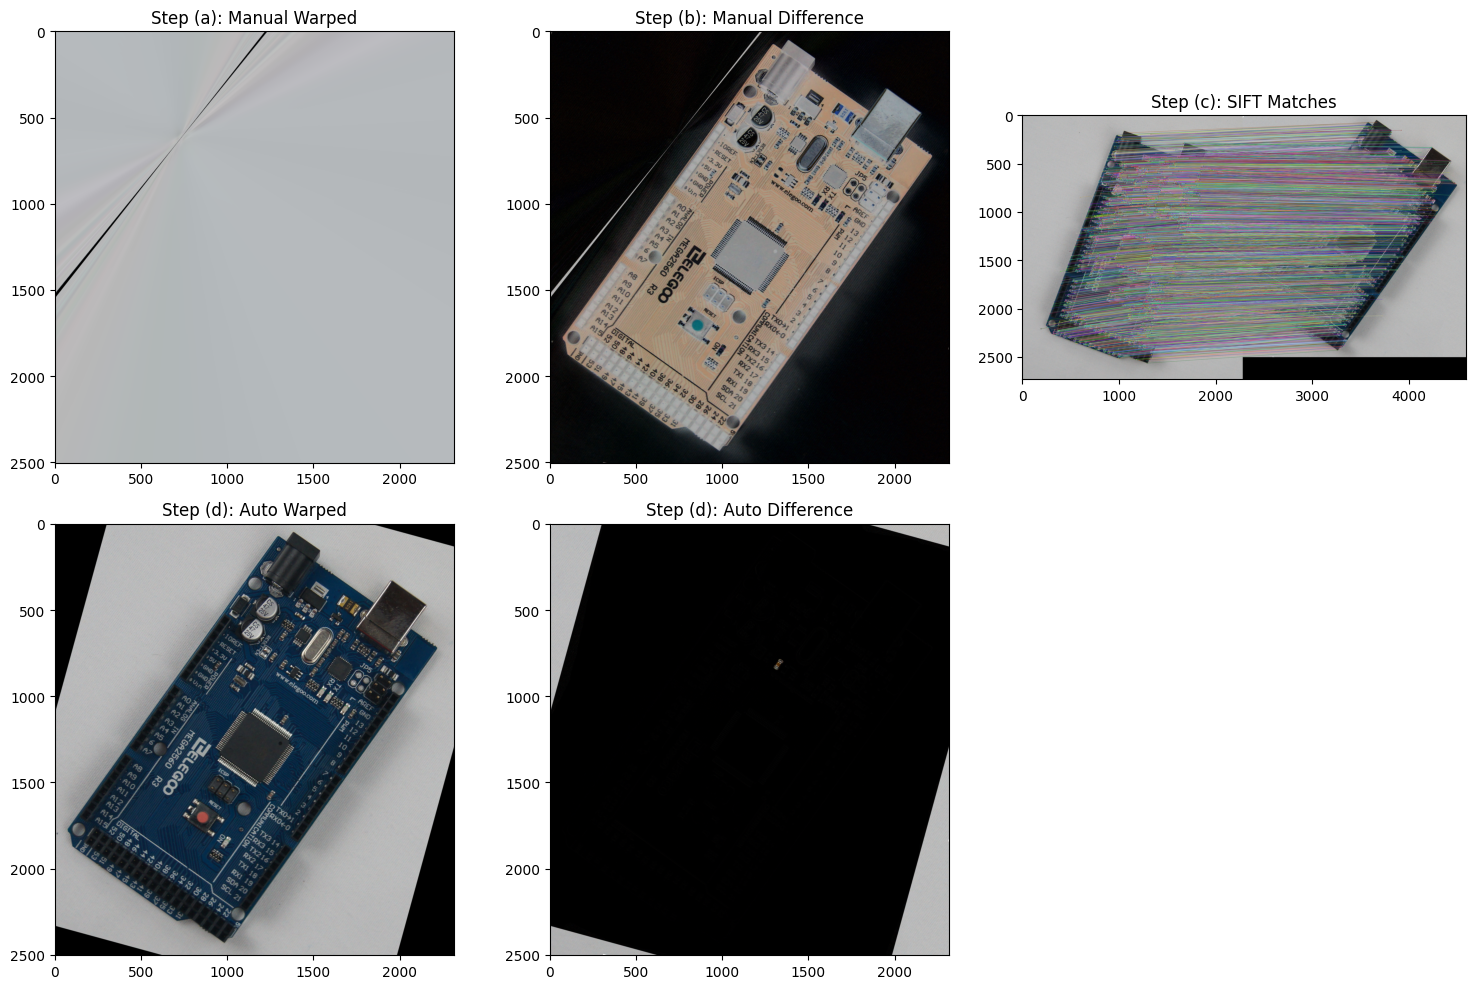

In [25]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1), plt.imshow(cv2.cvtColor(im1_warped_manual, cv2.COLOR_BGR2RGB)), plt.title('Step (a): Manual Warped')
plt.subplot(2, 3, 2), plt.imshow(cv2.cvtColor(diff_manual, cv2.COLOR_BGR2RGB)), plt.title('Step (b): Manual Difference')
plt.subplot(2, 3, 3), plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB)), plt.title('Step (c): SIFT Matches')
plt.subplot(2, 3, 4), plt.imshow(cv2.cvtColor(im1_warped_auto, cv2.COLOR_BGR2RGB)), plt.title('Step (d): Auto Warped')
plt.subplot(2, 3, 5), plt.imshow(cv2.cvtColor(diff_auto, cv2.COLOR_BGR2RGB)), plt.title('Step (d): Auto Difference')

plt.tight_layout()
plt.show()